# Terry Analytics Lab - Resource Guide

# Corpus Linguistics: Analyzing Film Criticism & Movie Reviews

**Text Analytics for Business**

In this notebook, we'll apply corpus linguistics methods to analyze a dataset of movie reviews, inspired by Kaggle datasets for Rotten Tomatoes and IMDB. Film criticism is a fantastic domain for text analytics because reviewers use highly specific, rhetorical language to persuade their audience.

## Learning Objectives
1. Perform **dispersion analysis** to track how specific cinematic terms distribute across different review sentiments.
2. Use an **Interactive KWIC (Key Word in Context)** tool to examine the syntactical environment of specific words.
3. Understand the math and intuition behind **Log-Likelihood ($G^2$)**.
4. Conduct **keyword analysis** to find statistically distinctive vocabulary that differentiates positive from negative film critique.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import warnings
import ipywidgets as widgets # Added for interactivity
from IPython.display import display

warnings.filterwarnings('ignore')

# Set style for visualizations - UGA colors
UGA_RED = '#BA0C2F'
UGA_TEAL = '#00A3AD'
UGA_BLACK = '#000000'

print("Libraries loaded successfully! Interactive widgets enabled.")

Libraries loaded successfully! Interactive widgets enabled.


## Part 1: Creating the Film Criticism Corpus

Instead of a massive Kaggle dataset that requires external downloads, we will use a representative sample corpus of movie reviews categorized by sentiment (Positive vs. Negative).

In business analytics, comparing two sub-corpora (like positive vs. negative reviews, or 5-star vs. 1-star ratings) allows us to identify the specific drivers of customer satisfaction.

In [ ]:
import pandas as pd
import re

# Sample film review excerpts categorized by sentiment
sample_reviews = [
    # Positive Reviews
    {"sentiment": "Positive", "text": "An absolute masterpiece of modern cinema. The cinematography is breathtaking, and the director manages to weave a complex narrative without ever losing pacing. The lead actor delivers a nuanced, Oscar-worthy performance that anchors the entire film."},
    {"sentiment": "Positive", "text": "A thrilling, action-packed ride from start to finish. The practical effects and stunt work are a breath of fresh air in an era dominated by CGI. While the plot is simple, the execution is flawless. Highly recommended."},
    {"sentiment": "Positive", "text": "This indie darling is a triumph of screenwriting. The dialogue feels incredibly authentic, capturing the awkward reality of coming of age. It's a quiet, introspective film that will stick with you long after the credits roll."},
    {"sentiment": "Positive", "text": "Visually stunning and emotionally resonant. The score perfectly complements the stunning cinematography. The director has created a rich, immersive world that demands to be seen on the biggest screen possible."},
    {"sentiment": "Positive", "text": "A brilliant satire that sharply critiques modern society. The script is razor-sharp, and the ensemble cast has perfect comedic timing. It manages to be both hilarious and deeply thought-provoking."},

    # Negative Reviews
    {"sentiment": "Negative", "text": "A complete disaster. The plot is a convoluted mess of cliches and unearned emotional beats. The pacing drags terribly in the second act, making the two-hour runtime feel like an eternity. A massive disappointment."},
    {"sentiment": "Negative", "text": "Despite a massive budget, the film feels incredibly hollow. The CGI is overused and visually exhausting, while the characters remain one-dimensional cardboard cutouts. The script relies entirely on cheap nostalgia rather than original ideas."},
    {"sentiment": "Negative", "text": "An absolute bore. The director attempts to be profound but ends up creating a pretentious, meandering slog. The dialogue is stilted, and the performances feel completely wooden and disconnected."},
    {"sentiment": "Negative", "text": "A generic, predictable thriller that brings absolutely nothing new to the genre. You can see every plot twist coming a mile away. The action sequences are so poorly edited and subjected to shaky-cam that you can barely tell what's happening."},
    {"sentiment": "Negative", "text": "A colossal waste of a talented cast. The screenplay forces great actors to deliver embarrassing dialogue. The tone is wildly inconsistent, shifting from slapstick comedy to dark melodrama without any logical transition."}
]

# Create DataFrame
df = pd.DataFrame(sample_reviews)

## Part 1.5: Text Preprocessing & Data Normalization

Before we can analyze text mathematically, we must normalize it. Raw text is messy; computers see "The", "the", and "the." as three completely distinct tokens.

In corpus linguistics, we typically perform several preprocessing steps:
1. **Lowercasing:** Standardizes the vocabulary so "Director" and "director" are counted together.
2. **Noise Removal (Punctuation):** Strips out commas, periods, and special characters. While punctuation can hold semantic meaning (like exclamation points for excitement), it generally interferes with word frequency counts.
3. **Stopword Removal:** Removes highly frequent grammatical filler words (e.g., "the", "a", "and", "is"). These words often dominate the frequency counts but carry very little analytical value for sentiment or topical analysis.
4. **Stemming / Lemmatization (Optional):** Reduces words to their root form (e.g., "running", "runs", "ran" $\rightarrow$ "run"). *Note: We are skipping this step to preserve the specific rhetorical tense used by reviewers.*

Let's build our corpus and define our cleaning functions.

In [ ]:
# Define a basic list of English stopwords
STOPWORDS = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
             'of', 'with', 'by', 'from', 'is', 'are', 'was', 'were', 'it', 'that',
             'this', 'these', 'those', 'as', 'be', 'has', 'have', 'had'}

def clean_text(text, remove_stopwords=True):
    """Advanced text cleaning for corpus analysis."""
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation (Keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    # 3. Remove Stopwords
    if remove_stopwords:
        words = text.split()
        words = [w for w in words if w not in STOPWORDS]
        text = ' '.join(words)

    return text

# Apply the cleaning function
df['text_clean'] = df['text'].apply(lambda x: clean_text(x, remove_stopwords=True))
df['raw_word_count'] = df['text'].apply(lambda x: len(x.split()))
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

print(f"Movie Review corpus created with {len(df)} documents")
print(f"Raw words in corpus: {df['raw_word_count'].sum():,}")
print(f"Clean words in corpus: {df['clean_word_count'].sum():,} (Noise and stopwords removed)")

Movie Review corpus created with 10 documents
Raw words in corpus: 337
Clean words in corpus: 226 (Noise and stopwords removed)


### Pre-processing Visualizer

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create a dedicated output area
out_prep = widgets.Output()

def interactive_preprocessing(text_index, lowercase, remove_punct, remove_stopwords):
    """Dynamically applies preprocessing steps to show students data transformation."""
    with out_prep:
        clear_output(wait=True)

        raw_text = df['text'].iloc[text_index]
        processed_text = raw_text

        print(f"--- ORIGINAL TEXT (Review #{text_index}) ---")
        print(raw_text)
        print("\n" + "="*70 + "\n")
        print("--- PROCESSED TEXT ---")

        # Step 1: Lowercase
        if lowercase:
            processed_text = processed_text.lower()

        # Step 2: Punctuation
        if remove_punct:
            processed_text = re.sub(r'[^a-zA-Z\s]', '', processed_text)
            processed_text = re.sub(r'\s+', ' ', processed_text).strip()

        # Step 3: Stopwords
        if remove_stopwords:
            words = processed_text.split()
            # Case-insensitive check so it works even if 'Lowercase' is unchecked
            words = [w for w in words if w.lower() not in STOPWORDS]
            processed_text = ' '.join(words)

        print(processed_text)

        # Calculate Data Loss
        orig_count = len(raw_text.split())
        new_count = len(processed_text.split()) if processed_text else 0
        loss_pct = ((orig_count - new_count) / orig_count) * 100 if orig_count > 0 else 0

        print("\n" + "-"*30)
        print(f"Original Word Count: {orig_count}")
        print(f"Current Word Count:  {new_count}")
        print(f"Data Reduction:      {loss_pct:.1f}%")

# Generate the UI Controls
print("Interactive Text Cleaning Visualizer")
print("Toggle the checkboxes to see how preprocessing alters the text and reduces data volume.")
print("-" * 70)

review_slider = widgets.IntSlider(value=0, min=0, max=len(df)-1, description='Review ID:')
cb_lower = widgets.Checkbox(value=False, description='1. Lowercase')
cb_punct = widgets.Checkbox(value=False, description='2. Remove Punctuation')
cb_stops = widgets.Checkbox(value=False, description='3. Remove Stopwords')

# Link controls to function
widgets.interactive_output(
    interactive_preprocessing,
    {'text_index': review_slider, 'lowercase': cb_lower, 'remove_punct': cb_punct, 'remove_stopwords': cb_stops}
)

# Display horizontally grouped checkboxes
checkbox_box = widgets.HBox([cb_lower, cb_punct, cb_stops])
display(widgets.VBox([review_slider, checkbox_box, out_prep]))

Interactive Text Cleaning Visualizer
Toggle the checkboxes to see how preprocessing alters the text and reduces data volume.
----------------------------------------------------------------------


## Part 2: Interactive KWIC (Key Word in Context)

**Why KWIC matters:**
Frequency alone doesn't tell us *how* a word is used. For example, the word "plot" might appear frequently in both positive and negative reviews. KWIC allows us to see the syntactic environment. Does "plot" co-occur with "brilliant" or "convoluted"?

**New Feature:** Below is an interactive widget. Future students can type any word into the text box and adjust the window size to instantly explore the corpus.

In [ ]:
import re
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# 1. FIX AND APPLY TEXT PREPROCESSING
# ==========================================
def clean_text(text):
    """Basic text cleaning for analysis."""
    text = text.lower()

    # Use a single backslash for \s inside a raw string to preserve spaces
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# Re-apply the fixed cleaning function to the dataframe
df['text_clean'] = df['text'].apply(clean_text)

# Verify the word counts look normal again!
df['word_count'] = df['text_clean'].apply(lambda x: len(x.split()))
print(f"Total words in corpus: {df['word_count'].sum():,}\n")


# ==========================================
# 2. ROBUST INTERACTIVE KWIC UI
# ==========================================
# Create a dedicated output area to capture the print statements
out = widgets.Output()

def interactive_kwic(target_word, window):
    # Route all print statements into the output widget
    with out:
        # Clear the old results smoothly before printing new ones
        clear_output(wait=True)

        if not target_word:
            return

        results = []
        target_lower = target_word.lower()
        texts = df['text_clean'].tolist()

        for text in texts:
            words = text.split()
            for i, word in enumerate(words):
                if word == target_lower or word.startswith(target_lower):
                    left_start = max(0, i - window)
                    right_end = min(len(words), i + window + 1)

                    left_context = ' '.join(words[left_start:i])
                    right_context = ' '.join(words[i+1:right_end])

                    results.append((left_context, word.upper(), right_context))

        if not results:
            print(f"No matches found for '{target_word}'.")
            return

        max_left = max(len(line[0]) for line in results)
        print(f"Showing matches for: {target_word.upper()}\n" + "="*70)
        for left, keyword, right in results:
            print(f"{left:>{max_left}}  [{keyword}]  {right}")

# Create the UI controls explicitly
target_input = widgets.Text(value='plot', description='Search Word:')
window_slider = widgets.IntSlider(value=5, min=2, max=10, step=1, description='Window Size:')

# Link the controls to the function
widgets.interactive_output(interactive_kwic, {'target_word': target_input, 'window': window_slider})

# Display the controls and the output area stacked vertically
display(widgets.VBox([target_input, window_slider, out]))

Total words in corpus: 337



## Part 3: Deep Dive into Log-Likelihood ($G^2$)

**Student Reference Guide: Understanding the Math**

Identifying keywords isn't as simple as finding the most frequent words. Words like "the", "and", and "movie" will be the most frequent in *both* positive and negative reviews. We need a statistical way to find words that are **unusually frequent** in one sub-corpus compared to another.

Enter the **Log-Likelihood ($G^2$)** test.

### 1. The Contingency Table
For every single word in our vocabulary, the algorithm builds a 2x2 contingency table. Let's imagine we are testing the word **"masterpiece"**:

|                    | Positive Reviews (Target) | Negative Reviews (Reference) | Total |
|--------------------|:-------------------------:|:----------------------------:|:-----:|
| **Freq of "masterpiece"** | a (e.g., 5)               | b (e.g., 0)                  | a+b   |
| **Freq of ALL other words**| c (e.g., 100)             | d (e.g., 120)                | c+d   |
| **Total Words**    | a+c                       | b+d                          | N     |

### 2. Calculating Expected Frequencies ($E$)
If the word "masterpiece" had no relationship to the sentiment of the review, how many times would we *expect* to see it in the Positive corpus based purely on chance?

### 3. The $G^2$ Formula
We compare the *Observed* frequencies (a, b, c, d) to the *Expected* frequencies ($E_a, E_b, E_c, E_d$).


### Why is this better than raw frequency?
1. **Size Normalization:** It perfectly handles corpora of different sizes (e.g., if we have 10,000 positive reviews but only 500 negative reviews).
2. **Statistical Rigor:** A $G^2$ score over **3.84** means we are 95% confident (p < 0.05) that the word's presence is not due to random chance. It is a true "keyword" of that specific sentiment.

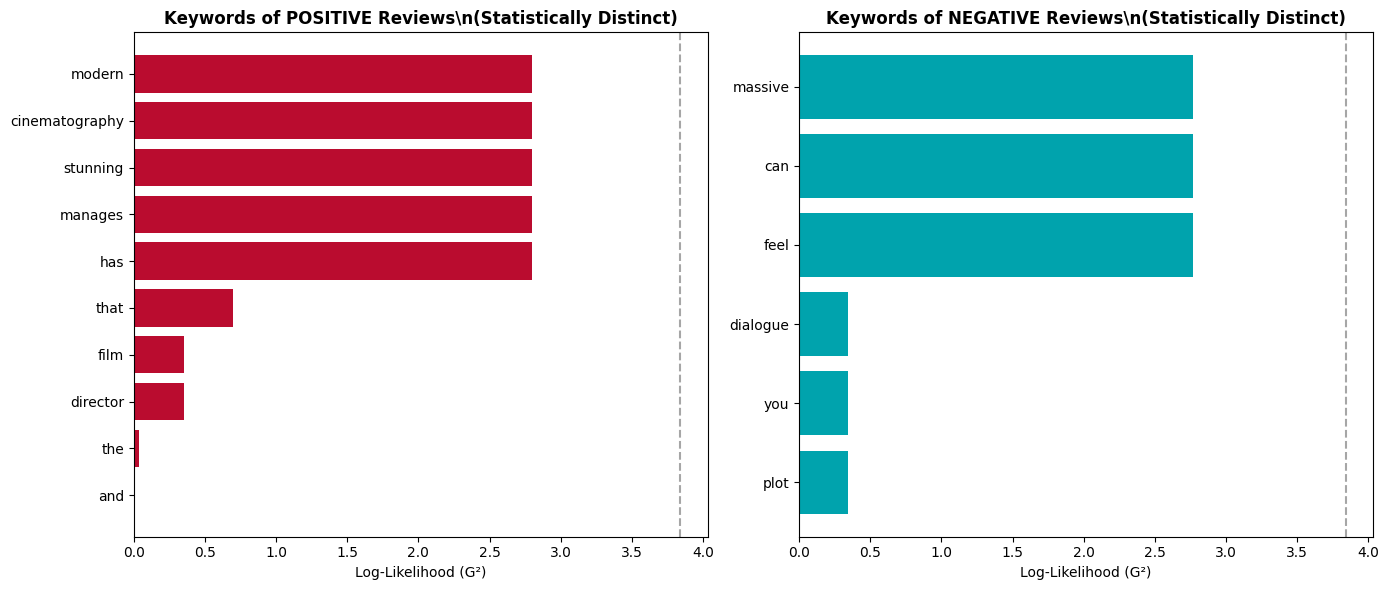

In [ ]:
def get_word_frequencies(texts):
    """Get word frequency counter from list of texts."""
    all_words = []
    for text in texts:
        all_words.extend(text.split())
    return Counter(all_words)

def calculate_keywords(target_freq, reference_freq, min_freq=2):
    """Calculate keywords using Log-Likelihood (G²)."""
    total_target = sum(target_freq.values())
    total_reference = sum(reference_freq.values())

    vocabulary = [w for w in target_freq if target_freq[w] >= min_freq and w.isalpha() and len(w) > 2]
    results = []

    for word in vocabulary:
        a = target_freq[word]
        b = reference_freq.get(word, 0)
        c = total_target - a
        d = total_reference - b

        total = a + b + c + d

        a_exp = ((a + b) * (a + c)) / total if total > 0 else 0
        b_exp = ((a + b) * (b + d)) / total if total > 0 else 0
        c_exp = ((c + d) * (a + c)) / total if total > 0 else 0
        d_exp = ((c + d) * (b + d)) / total if total > 0 else 0

        def safe_ll(o, e):
            if o == 0 or e == 0: return 0
            return o * np.log(o / e)

        g2 = 2 * (safe_ll(a, a_exp) + safe_ll(b, b_exp) + safe_ll(c, c_exp) + safe_ll(d, d_exp))
        preference = 'Positive' if a > a_exp else 'Negative'

        results.append({
            'word': word, 'target_freq': a, 'reference_freq': b,
            'g2': round(g2, 2), 'associated_sentiment': preference
        })

    return pd.DataFrame(results).sort_values('g2', ascending=False)

# Execute Keyword Analysis
texts_pos = df[df['sentiment'] == 'Positive']['text_clean'].tolist()
texts_neg = df[df['sentiment'] == 'Negative']['text_clean'].tolist()

freq_pos = get_word_frequencies(texts_pos)
freq_neg = get_word_frequencies(texts_neg)

keywords_df = calculate_keywords(freq_pos, freq_neg, min_freq=2)

# Visualize top keywords
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive Keywords
ax1 = axes[0]
top_pos = keywords_df[keywords_df['associated_sentiment'] == 'Positive'].head(10)
if len(top_pos) > 0:
    ax1.barh(range(len(top_pos)), top_pos['g2'], color=UGA_RED)
    ax1.set_yticks(range(len(top_pos)))
    ax1.set_yticklabels(top_pos['word'])
    ax1.invert_yaxis()
    ax1.axvline(x=3.84, color='gray', linestyle='--', alpha=0.7, label='p<0.05')
ax1.set_xlabel('Log-Likelihood (G²)')
ax1.set_title('Keywords of POSITIVE Reviews\\n(Statistically Distinct)', fontweight='bold')

# Negative Keywords
# To find words specific to Negative reviews, we flip the target and reference
keywords_neg_df = calculate_keywords(freq_neg, freq_pos, min_freq=2)
ax2 = axes[1]
top_neg = keywords_neg_df[keywords_neg_df['associated_sentiment'] == 'Positive'].head(10) # 'Positive' here means mathematically associated with the new target (Negative reviews)
if len(top_neg) > 0:
    ax2.barh(range(len(top_neg)), top_neg['g2'], color=UGA_TEAL)
    ax2.set_yticks(range(len(top_neg)))
    ax2.set_yticklabels(top_neg['word'])
    ax2.invert_yaxis()
    ax2.axvline(x=3.84, color='gray', linestyle='--', alpha=0.7, label='p<0.05')
ax2.set_xlabel('Log-Likelihood (G²)')
ax2.set_title('Keywords of NEGATIVE Reviews\\n(Statistically Distinct)', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Make sure to run !pip install pyvis networkx in your environment first
!pip install pyvis networkx

import networkx as nx
from pyvis.network import Network
import ipywidgets as widgets
from IPython.display import display, HTML
from collections import Counter

def interactive_collocation_network(target_word, window=5, min_freq=1):
    """
    Builds a dynamic, physics-based network graph of words that co-occur.
    """
    if not target_word:
        print("Please enter a target word.")
        return

    target_lower = target_word.lower()
    texts = df['text_clean'].tolist()

    # Basic stopwords to keep the graph clean
    stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                 'of', 'with', 'by', 'from', 'is', 'are', 'was', 'were', 'be', 'been',
                 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
                 'could', 'should', 'may', 'might', 'must', 'shall', 'can', 'this',
                 'that', 'these', 'those', 'it', 'its', 'as', 'if', 'not', 'no', 'so',
                 'than', 'too', 'very', 'just', 'also', 'only', 'our', 'we', 'they',
                 'their', 'which', 'who', 'what', 'when', 'where', 'more', 'some', 'any'}

    collocates = Counter()

    # Scan corpus for collocations
    for text in texts:
        words = text.split()
        for i, word in enumerate(words):
            if word == target_lower or word.startswith(target_lower):
                left_start = max(0, i - window)
                right_end = min(len(words), i + window + 1)
                context_words = words[left_start:i] + words[i+1:right_end]

                for cw in context_words:
                    if cw not in stopwords and cw != target_lower and len(cw) > 2 and cw.isalpha():
                        collocates[cw] += 1

    # Filter by minimum frequency
    valid_collocates = {k: v for k, v in collocates.items() if v >= min_freq}

    if not valid_collocates:
        print(f"No significant collocates found for '{target_word}' with current settings.")
        return

    # Initialize networkx graph
    G = nx.Graph()

    # Add the central target word node (Colored UGA Red)
    G.add_node(target_lower, size=25, title="Target Word", color=UGA_RED)

    # Add collocate nodes and edges
    for coll, freq in valid_collocates.items():
        # Node size scales with frequency (Colored UGA Teal)
        G.add_node(coll, size=10 + (freq * 3), title=f"Frequency: {freq}", color=UGA_TEAL)
        G.add_edge(target_lower, coll, value=freq, title=f"Co-occurrences: {freq}", color="#AAAAAA")

    # Build pyvis network (cdn_resources='remote' ensures it works in Jupyter/Colab)
    net = Network(notebook=True, width="100%", height="500px", bgcolor="#ffffff", font_color="black", cdn_resources='remote')
    net.from_nx(G)

    # Add physics for the "bouncy" interactive effect
    net.repulsion(node_distance=120, central_gravity=0.33, spring_length=110, spring_strength=0.10, damping=0.95)

    # Save the widget to an HTML file and display it
    graph_html = net.generate_html()
    with open("collocation_graph.html", "w") as f:
        f.write(graph_html)

    display(HTML("collocation_graph.html"))

# Generate the interactive UI for the students
print("Interactive Collocation Network Graph")
print("Drag the nodes around to explore the semantic relationships!")
print("="*70)

widgets.interact(
    interactive_collocation_network,
    target_word=widgets.Text(value='plot', description='Search Word:'),
    window=widgets.IntSlider(value=5, min=1, max=15, step=1, description='Window:'),
    min_freq=widgets.IntSlider(value=1, min=1, max=5, step=1, description='Min Freq:')
);

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.6 MB/s eta 0:00:00
Interactive Collocation Network Graph
Drag the nodes around to explore the semantic relationships!


interactive(children=(Text(value='plot', description='Search Word:'), IntSlider(value=5, description='Window:'…

## Part 4: Lexical Dispersion Analysis (Normalized Frequency)

**Student Reference Guide:**
Raw frequency counts can be misleading if one sub-corpus is much larger than another. For example, if we have 10,000 words of negative reviews and only 2,000 words of positive reviews, the word "director" will naturally appear more often in the negative pile.

To fix this, we calculate the **Normalized Frequency** (occurrences per 1,000 words). This allows for an apples-to-apples comparison of how specific vocabulary is *dispersed* across different categories. Let's look at how specific cinematic terms are distributed across Positive and Negative reviews.

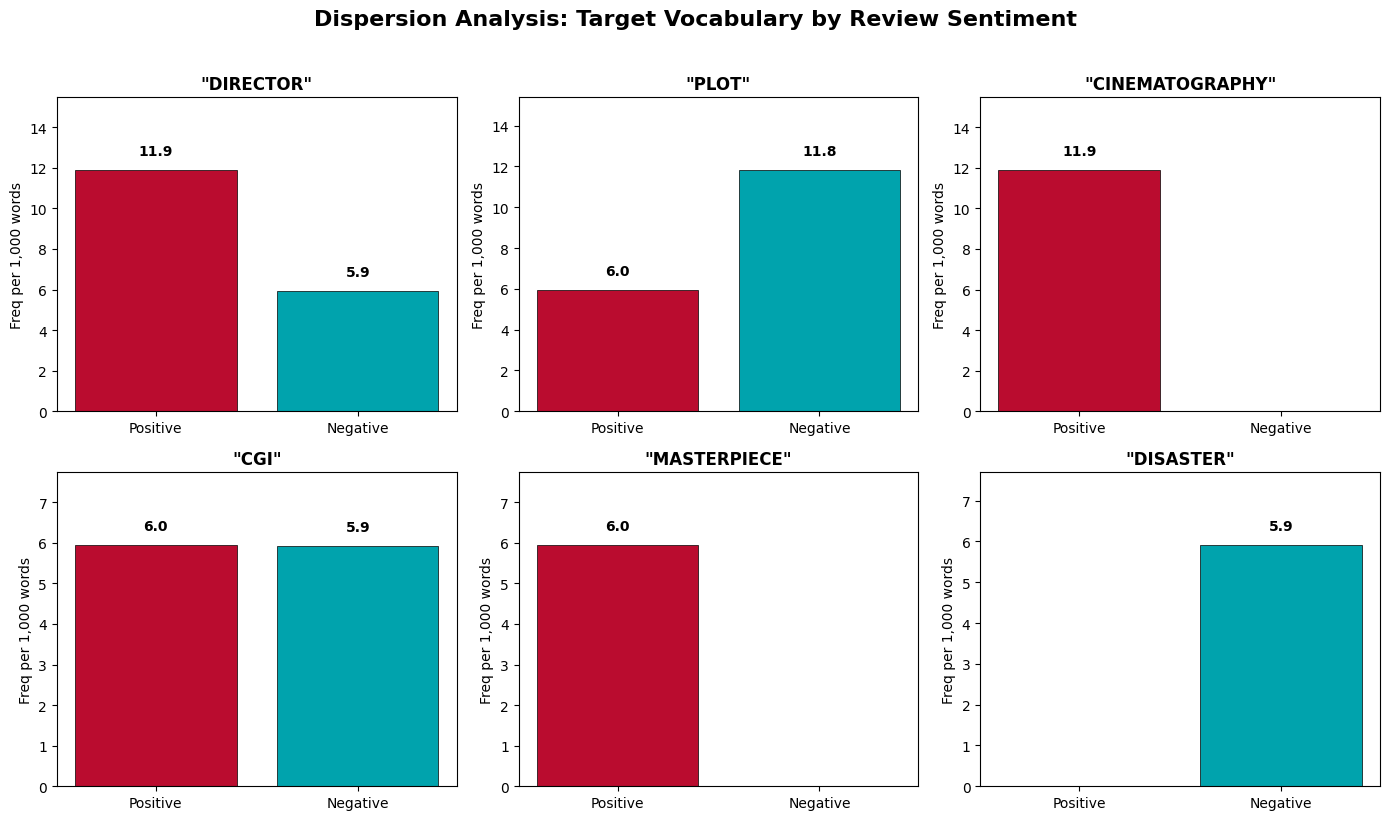

In [ ]:
import matplotlib.pyplot as plt

# 1. Define target vocabulary to track
target_words = ['director', 'plot', 'cinematography', 'cgi', 'masterpiece', 'disaster']

# 2. Calculate total word counts per sentiment for normalization
# (Using the clean_text column we generated earlier)
total_words_pos = sum([len(text.split()) for text in df[df['sentiment'] == 'Positive']['text_clean']])
total_words_neg = sum([len(text.split()) for text in df[df['sentiment'] == 'Negative']['text_clean']])

# 3. Calculate normalized frequencies
dispersion_results = {}
for word in target_words:
    pos_count = sum([text.split().count(word) for text in df[df['sentiment'] == 'Positive']['text_clean']])
    neg_count = sum([text.split().count(word) for text in df[df['sentiment'] == 'Negative']['text_clean']])

    # Normalize: (Word Count / Total Corpus Words) * 1000
    dispersion_results[word] = {
        'Positive': (pos_count / total_words_pos) * 1000 if total_words_pos > 0 else 0,
        'Negative': (neg_count / total_words_neg) * 1000 if total_words_neg > 0 else 0
    }

# 4. Visualize dispersion patterns
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sentiments = ['Positive', 'Negative']
colors = [UGA_RED, UGA_TEAL] # Using our custom brand colors

for idx, word in enumerate(target_words):
    ax = axes[idx]

    # Extract values for the plot
    vals = [dispersion_results[word]['Positive'], dispersion_results[word]['Negative']]

    # Generate bars
    bars = ax.bar(sentiments, vals, color=colors, edgecolor='black', linewidth=0.5)

    # Formatting
    ax.set_title(f'"{word.upper()}"', fontsize=12, fontweight='bold')
    ax.set_ylabel('Freq per 1,000 words')

    # Dynamically set y-limit so the text labels don't get cut off at the top
    max_val = max(vals) if max(vals) > 0 else 1
    ax.set_ylim(0, max_val + (max_val * 0.3))

    # Add value labels on bars
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max_val * 0.05),
                   f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Dispersion Analysis: Target Vocabulary by Review Sentiment',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

We see that neutral technical terms like "director", "plot", and "CGI have relatively even dispersion across both sentiments. However, emotionally charged words like, "masterpiece" and "disaster show aggresive, asymmetric spikes.